In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==========================================================
# 2. Import Library
# ==========================================================
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
# ==========================================================
# 3. Membaca Dataset
# ==========================================================
folder_path = "/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/Youtube"

embedding_df = pd.read_csv(os.path.join(folder_path, "yt_embed_lightgbm.csv"))
label_df = pd.read_csv(os.path.join(folder_path, "yt_pseudo.csv"))

print("Embedding :", embedding_df.shape)
print("Pseudo    :", label_df.shape)

Embedding : (93878, 769)
Pseudo    : (93878, 3)


In [4]:
# ==========================================================
# 4. Merge Dataset
# ==========================================================
df = pd.merge(
    embedding_df,
    label_df[["yt_clean", "label_sentimen", "confidence_score"]],
    on="yt_clean",
    how="inner"
)

print(df.head())
print(df.shape)

                                            yt_clean     emb_0     emb_1  \
0  kalo rakyat kompak siapapun anggota dari insti...  0.020442 -0.139247   
1                                           ❤ mantap  1.059883 -0.151195   
2            ahmad syahroni = amit amit jabang bayi. -0.632922 -0.704873   
3  alhamdulillah tamunya satroni buanyak bersilst...  0.093417 -0.375987   
4  waduuh. indonesia kok seperti nepal ya?? tahan... -0.211096 -0.438964   

      emb_2     emb_3     emb_4     emb_5     emb_6     emb_7     emb_8  ...  \
0 -0.913200  0.112860 -0.737026 -0.280612  0.531690  0.526232  0.433014  ...   
1 -0.406238 -0.636054 -0.030048 -1.034087  0.538688  0.557629  0.692233  ...   
2 -0.592890  0.014090 -0.461966 -0.869192  0.166097  1.069114  0.451185  ...   
3 -0.451100  0.238015 -1.121330 -0.295250 -0.285193  0.341410  0.287571  ...   
4 -0.618619  0.421524 -0.794827 -0.465556  0.123153  1.010299  0.470776  ...   

    emb_760   emb_761   emb_762   emb_763   emb_764   emb_765 

In [5]:
# ==========================================================
# 5. Filter Confidence Score
# ==========================================================
# Gunakan jika ingin hanya memakai pseudo label yang yakin

df = df[df["confidence_score"] >= 0.80].reset_index(drop=True)

print("Jumlah data setelah filter :", len(df))

Jumlah data setelah filter : 79031


In [6]:
# ==========================================================
# 6. Menentukan Feature dan Label
# ==========================================================
embedding_cols = [col for col in df.columns if col.startswith("emb_")]

X = df[embedding_cols].values

y = df["label_sentimen"]

print("Jumlah fitur :", len(embedding_cols))
print("Shape X :", X.shape)

Jumlah fitur : 768
Shape X : (79031, 768)


In [7]:
# ==========================================================
# 7. Label Encoding
# ==========================================================
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Label kelas :", encoder.classes_)

Label kelas : ['negative' 'neutral' 'positive']


In [8]:
# ==========================================================
# 8. Train Test Split
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (63224, 768)
Test  : (15807, 768)


In [9]:
# ==========================================================
# 9. Training LightGBM
# ==========================================================
model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    learning_rate=0.05,
    n_estimators=300,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.115992 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 63224, number of used features: 768
[LightGBM] [Info] Start training from score -0.351667
[LightGBM] [Info] Start training from score -1.887320
[LightGBM] [Info] Start training from score -1.930965


LGBMClassifier(learning_rate=0.05, n_estimators=300, num_class=3,
               objective='multiclass', random_state=42)

In [10]:
# ==========================================================
# 10. Prediksi
# ==========================================================
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [11]:
# ==========================================================
# 11. Evaluasi Model
# ==========================================================
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("="*50)
print("HASIL EVALUASI LIGHTGBM")
print("="*50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

HASIL EVALUASI LIGHTGBM
Accuracy  : 0.9234
Precision : 0.9227
Recall    : 0.9234
F1 Score  : 0.9212


In [12]:
# ==========================================================
# 12. Classification Report
# ==========================================================
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

    negative       0.93      0.98      0.95     11121
     neutral       0.90      0.82      0.86      2394
    positive       0.91      0.76      0.83      2292

    accuracy                           0.92     15807
   macro avg       0.92      0.85      0.88     15807
weighted avg       0.92      0.92      0.92     15807



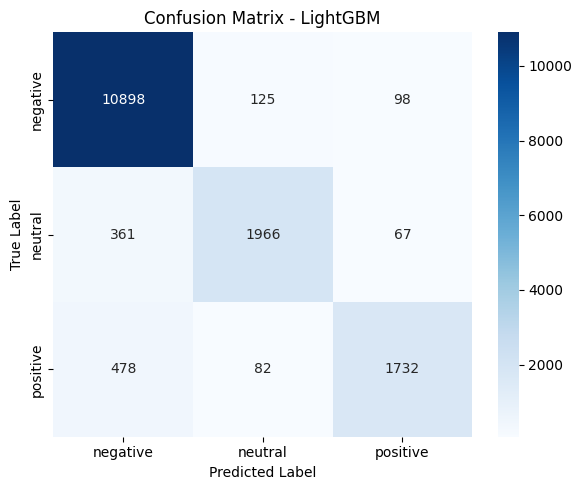

In [13]:
# ==========================================================
# 13. Confusion Matrix
# ==========================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [14]:
df = df[df["confidence_score"] > 0.8].reset_index(drop=True)

print(f"Jumlah data setelah filter: {len(df):,}")
print(df["label_sentimen"].value_counts())

Jumlah data setelah filter: 79,031
label_sentimen
negative    55600
neutral     11971
positive    11460
Name: count, dtype: int64
